In [15]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage 
from langchain_core.prompts import ChatPromptTemplate

from dotenv import load_dotenv

from pydantic import BaseModel, Field
import os
load_dotenv()   

True

In [16]:
load_dotenv()
generator_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
)

evaluator_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
)

optimizer_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
)   

In [17]:
#State and Graph Definition
class PostState(TypedDict):
    topic: str
    content: str
    evaluation: Literal["good","bad"]
    feedback: str
    iteration: int 
    max_iterations: int


In [18]:
class PostEvaluation(BaseModel):
    evaluation: Literal["good","bad"] = Field(description="Evaluation of the post quality")
    feedback: str = Field(description="Constructive feedback for improvement")

structured_evaluator_llm = evaluator_llm.with_structured_output(PostEvaluation)

In [43]:
def generate_post(state: PostState) -> PostState:
    print(f"Generating post for topic: {state['topic']} (Iteration {state['iteration']}/{state['max_iterations']})")
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a LinkedIn content creator. Generate a LinkedIn post based on the given topic. Limit the post to 100 words."),
        ("human", "Topic: {topic}")
    ])

    response = generator_llm.invoke(prompt.format_prompt(topic=state['topic']).to_messages())
    print(f"Generated post: {response.content}")
    return {'content': str(response.content)}

In [32]:
def evaluate_post(state: PostState) -> PostState:
    print(f"Evaluating post content: {state['content']}")
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a LinkedIn content evaluator. Evaluate the given LinkedIn post based on its relevance, engagement potential, and clarity.
Provide a concise evaluation of "good" or "bad" along with specific feedback for improvement."""),
        ("human", "Post Content: {content}")
    ])

    response = structured_evaluator_llm.invoke(prompt.format_prompt(content=state['content']).to_messages())

    print(f"Evaluation: {response.evaluation}, Feedback: {response.feedback}")
    return {'evaluation': str(response.evaluation), 'feedback': str(response.feedback)}

In [33]:
def optimize_post(state: PostState) -> PostState:
    print(f"Optimizing post based on feedback: {state['feedback']}")
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a LinkedIn content optimizer. Based on the provided feedback, optimize the LinkedIn post to enhance its relevance, engagement potential, and clarity."""),
        ("human", "Original Post: {content}\nFeedback: {feedback}")
    ])

    response = optimizer_llm.invoke(prompt.format_prompt(content=state['content'], feedback=state['feedback']).to_messages())

    iteration = state['iteration'] + 1
    print(f"Optimized post: {response.content} (Iteration {iteration}/{state['max_iterations']})")
    return {'content': str(response.content), 'iteration': iteration}

In [ ]:
def route_evaluation(state: PostState) -> str:
    if state['evaluation'] == 'good' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_optimization'

In [40]:
graph = StateGraph(PostState)

graph.add_node('generate_post', generate_post)
graph.add_node('evaluate_post', evaluate_post)
graph.add_node('optimize_post', optimize_post)

graph.add_edge(START, 'generate_post')
graph.add_edge('generate_post', 'evaluate_post')

graph.add_conditional_edges('evaluate_post', route_evaluation,{'approved': END, 'needs_optimization': 'optimize_post'})
graph.add_edge('optimize_post', 'evaluate_post')

workflow = graph.compile()
               

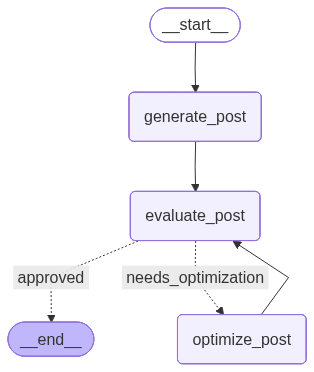

In [41]:
workflow

In [45]:
initial_state = {
    'topic': "Real reason for layoffs in tech industry",
    'iteration': 1,
    'max_iterations': 3
}

workflow.invoke(initial_state)

Generating post for topic: Real reason for layoffs in tech industry (Iteration 1/3)
Generated post: 🚨 The Real Reason for Layoffs in the Tech Industry 🚨

As we’ve seen in recent months, the tech industry has been hit hard with significant layoffs, leaving many to wonder: what’s really going on? 🤔

While the headlines often focus on economic downturns, inflation, or rising interest rates, the truth is more nuanced. Here are a few key factors driving these decisions:

1️⃣ **Over-Hiring During the Pandemic**: Many tech companies ramped up hiring during the pandemic, anticipating sustained growth. As we transition back to a more normalized economy, the reality is that some of these roles are no longer necessary. Companies are recalibrating to align with current market demands.

2️⃣ **Shift in Consumer Behavior**: The pandemic accelerated digital transformation, but as life returns to normal, some consumer habits are reverting. Companies that thrived on pandemic-driven demand are now facing

KeyError: '__end__'